<a href="https://colab.research.google.com/github/Pavithra2006-15/Data_Science_Hackathon/blob/main/Placement_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Direct CSV URL from Hugging Face
url = "https://huggingface.co/datasets/jason1966/alhamdulliah123_student-placement-and-skills-analytics-dataset-2025/resolve/main/Student_Placement_Skills_2025.csv"

# Load dataset directly
df = pd.read_csv(url)

# Display basic information
print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (600, 13)


,Student_ID,Gender,Age,Degree,CGPA,Internships_Count,Projects_Count,Certifications_Count,Technical_Skills_Score_100,Communication_Skills_Score_100,Aptitude_Test_Score_100,Placement_Offer,Salary_Offered_USD
0,1,Male,19,Business,2.56,3,8,0,64,42,57,Yes,8047.08
1,2,Female,27,Engineering,3.66,0,5,2,78,54,40,Yes,3518.56
2,3,Male,26,Data Science,3.73,0,5,1,61,54,49,No,11791.75
3,4,Male,18,Computer Science,2.21,2,8,5,66,42,72,Yes,13946.28
4,5,Male,20,Business,2.59,3,9,2,69,50,53,No,10951.66


In [ ]:
# Check columns
print("Columns:")
print(df.columns.tolist())

# Dataset information
print("\nDataset Information:")
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Statistical summary
print("\nDescriptive Statistics:")
display(df.describe())

Columns:
['Student_ID', 'Gender', 'Age', 'Degree', 'CGPA', 'Internships_Count', 'Projects_Count', 'Certifications_Count', 'Technical_Skills_Score_100', 'Communication_Skills_Score_100', 'Aptitude_Test_Score_100', 'Placement_Offer', 'Salary_Offered_USD']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Student_ID                      600 non-null    int64  
 1   Gender                          600 non-null    object 
 2   Age                             600 non-null    int64  
 3   Degree                          600 non-null    object 
 4   CGPA                            600 non-null    float64
 5   Internships_Count               600 non-null    int64  
 6   Projects_Count                  600 non-null    int64  
 7   Certifications_Count            600 non-null    int64  
 8   Tech

,Student_ID,Age,CGPA,Internships_Count,Projects_Count,Certifications_Count,Technical_Skills_Score_100,Communication_Skills_Score_100,Aptitude_Test_Score_100,Salary_Offered_USD
count,600.000000,600.000000,600.000000,600.00000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,300.500000,23.558333,2.978433,2.01500,5.123333,2.583333,69.380000,68.913333,69.426667,11577.438233
std,173.349358,3.455889,0.584822,1.43697,2.632427,1.713071,17.374658,17.359765,17.769192,4734.794274
min,1.000000,18.000000,2.000000,0.00000,1.000000,0.000000,40.000000,40.000000,40.000000,3127.200000
25%,150.750000,21.000000,2.467500,1.00000,3.000000,1.000000,55.000000,54.000000,54.000000,7348.690000
50%,300.500000,24.000000,2.955000,2.00000,5.000000,3.000000,69.000000,68.000000,69.000000,11763.735000
75%,450.250000,26.000000,3.492500,3.00000,7.000000,4.000000,84.000000,84.000000,86.000000,15551.750000
max,600.000000,29.000000,3.990000,4.00000,9.000000,5.000000,99.000000,99.000000,99.000000,19998.130000


In [ ]:
# Step 2: Clean the dataset

# Remove duplicate rows
df = df.drop_duplicates()

# Remove duplicate Student IDs
df = df.drop_duplicates(subset="Student_ID")

# Convert numeric columns to numbers
numeric_cols = [
    "Age",
    "CGPA",
    "Internships_Count",
    "Projects_Count",
    "Certifications_Count",
    "Technical_Skills_Score_100",
    "Communication_Skills_Score_100",
    "Aptitude_Test_Score_100",
    "Salary_Offered_USD"
]

df[numeric_cols] = df[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

# Fill missing numeric values with median
df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

# Fill missing categorical values with mode
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Degree"] = df["Degree"].fillna(df["Degree"].mode()[0])
df["Placement_Offer"] = df["Placement_Offer"].fillna(
    df["Placement_Offer"].mode()[0]
)

# Clean text values
df["Gender"] = df["Gender"].str.strip()
df["Degree"] = df["Degree"].str.strip()
df["Placement_Offer"] = df["Placement_Offer"].str.strip()

print("Dataset cleaned successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset cleaned successfully!
Rows: 600
Columns: 13


In [ ]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# View cleaned dataset
display(df.head())

Missing values:
Student_ID                        0
Gender                            0
Age                               0
Degree                            0
CGPA                              0
Internships_Count                 0
Projects_Count                    0
Certifications_Count              0
Technical_Skills_Score_100        0
Communication_Skills_Score_100    0
Aptitude_Test_Score_100           0
Placement_Offer                   0
Salary_Offered_USD                0
dtype: int64

Duplicate rows: 0


,Student_ID,Gender,Age,Degree,CGPA,Internships_Count,Projects_Count,Certifications_Count,Technical_Skills_Score_100,Communication_Skills_Score_100,Aptitude_Test_Score_100,Placement_Offer,Salary_Offered_USD
0,1,Male,19,Business,2.56,3,8,0,64,42,57,Yes,8047.08
1,2,Female,27,Engineering,3.66,0,5,2,78,54,40,Yes,3518.56
2,3,Male,26,Data Science,3.73,0,5,1,61,54,49,No,11791.75
3,4,Male,18,Computer Science,2.21,2,8,5,66,42,72,Yes,13946.28
4,5,Male,20,Business,2.59,3,9,2,69,50,53,No,10951.66


In [ ]:
# Dataset shape
print("Rows and Columns:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

Rows and Columns: (600, 13)

Columns:
['Student_ID', 'Gender', 'Age', 'Degree', 'CGPA', 'Internships_Count', 'Projects_Count', 'Certifications_Count', 'Technical_Skills_Score_100', 'Communication_Skills_Score_100', 'Aptitude_Test_Score_100', 'Placement_Offer', 'Salary_Offered_USD']

Data Types:
Student_ID                          int64
Gender                             object
Age                                 int64
Degree                             object
CGPA                              float64
Internships_Count                   int64
Projects_Count                      int64
Certifications_Count                int64
Technical_Skills_Score_100          int64
Communication_Skills_Score_100      int64
Aptitude_Test_Score_100             int64
Placement_Offer                    object
Salary_Offered_USD                float64
dtype: object


In [ ]:
df.describe()

,Student_ID,Age,CGPA,Internships_Count,Projects_Count,Certifications_Count,Technical_Skills_Score_100,Communication_Skills_Score_100,Aptitude_Test_Score_100,Salary_Offered_USD
count,600.000000,600.000000,600.000000,600.00000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,300.500000,23.558333,2.978433,2.01500,5.123333,2.583333,69.380000,68.913333,69.426667,11577.438233
std,173.349358,3.455889,0.584822,1.43697,2.632427,1.713071,17.374658,17.359765,17.769192,4734.794274
min,1.000000,18.000000,2.000000,0.00000,1.000000,0.000000,40.000000,40.000000,40.000000,3127.200000
25%,150.750000,21.000000,2.467500,1.00000,3.000000,1.000000,55.000000,54.000000,54.000000,7348.690000
50%,300.500000,24.000000,2.955000,2.00000,5.000000,3.000000,69.000000,68.000000,69.000000,11763.735000
75%,450.250000,26.000000,3.492500,3.00000,7.000000,4.000000,84.000000,84.000000,86.000000,15551.750000
max,600.000000,29.000000,3.990000,4.00000,9.000000,5.000000,99.000000,99.000000,99.000000,19998.130000


In [ ]:
# Compare students based on placement offer
df.groupby("Placement_Offer")[
    [
        "CGPA",
        "Internships_Count",
        "Projects_Count",
        "Certifications_Count",
        "Technical_Skills_Score_100",
        "Communication_Skills_Score_100",
        "Aptitude_Test_Score_100",
        "Salary_Offered_USD"
    ]
].mean().round(2)

,CGPA,Internships_Count,Projects_Count,Certifications_Count,Technical_Skills_Score_100,Communication_Skills_Score_100,Aptitude_Test_Score_100,Salary_Offered_USD
Placement_Offer,,,,,,,,
No,3.05,2.04,5.32,2.63,69.10,68.74,68.83,11601.94
Yes,2.94,2.00,5.01,2.56,69.53,69.01,69.76,11563.95


In [ ]:
print("Average CGPA:", round(df["CGPA"].mean(), 2))
print("Average Technical Skill Score:", round(df["Technical_Skills_Score_100"].mean(), 2))
print("Average Communication Score:", round(df["Communication_Skills_Score_100"].mean(), 2))
print("Average Projects:", round(df["Projects_Count"].mean(), 2))
print("Average Internships:", round(df["Internships_Count"].mean(), 2))
print("Average Certifications:", round(df["Certifications_Count"].mean(), 2))
print("Average Salary:", round(df["Salary_Offered_USD"].mean(), 2))

Average CGPA: 2.98
Average Technical Skill Score: 69.38
Average Communication Score: 68.91
Average Projects: 5.12
Average Internships: 2.02
Average Certifications: 2.58
Average Salary: 11577.44


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

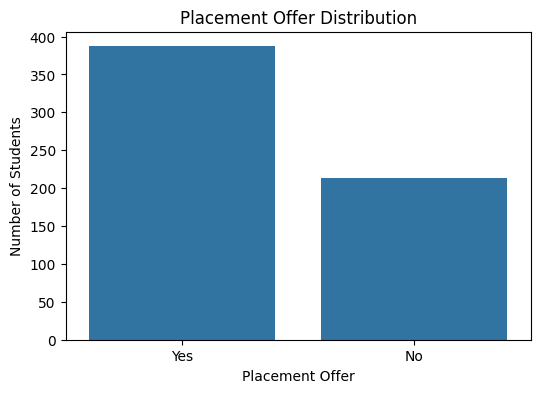

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Placement_Offer")

plt.title("Placement Offer Distribution")
plt.xlabel("Placement Offer")
plt.ylabel("Number of Students")

plt.show()

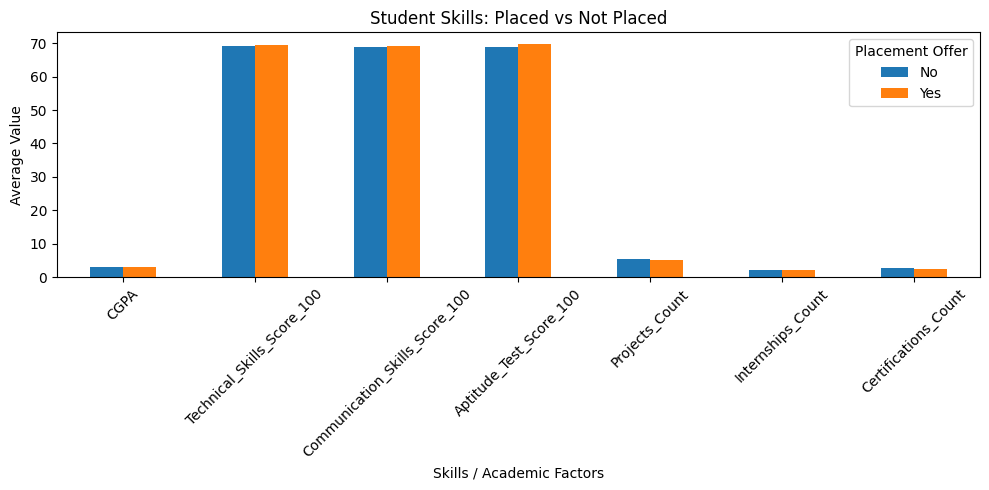

In [ ]:
skills = [
    "CGPA",
    "Technical_Skills_Score_100",
    "Communication_Skills_Score_100",
    "Aptitude_Test_Score_100",
    "Projects_Count",
    "Internships_Count",
    "Certifications_Count"
]

df.groupby("Placement_Offer")[skills].mean().T.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Student Skills: Placed vs Not Placed")
plt.xlabel("Skills / Academic Factors")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(title="Placement Offer")

plt.tight_layout()
plt.show()

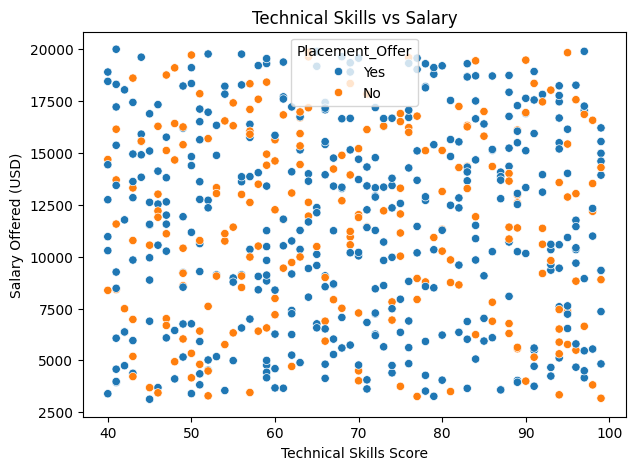

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Technical_Skills_Score_100",
    y="Salary_Offered_USD",
    hue="Placement_Offer"
)

plt.title("Technical Skills vs Salary")
plt.xlabel("Technical Skills Score")
plt.ylabel("Salary Offered (USD)")

plt.show()

In [ ]:
df["Placement_Target"] = df["Placement_Offer"].map({
    "Yes": 1,
    "No": 0
})

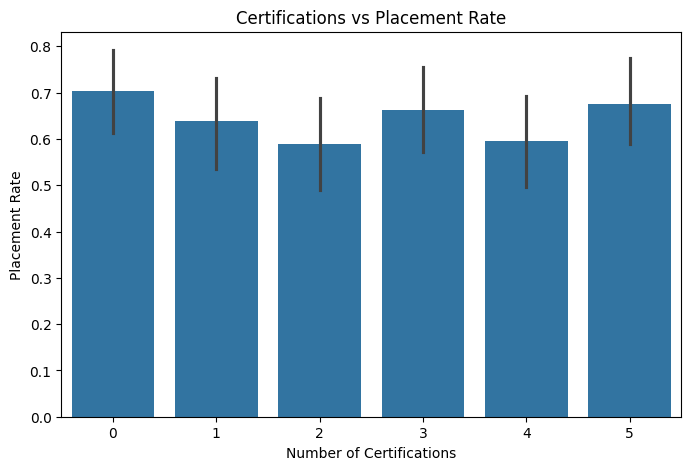

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Certifications_Count",
    y="Placement_Target"
)

plt.title("Certifications vs Placement Rate")
plt.xlabel("Number of Certifications")
plt.ylabel("Placement Rate")

plt.show()

In [ ]:
# Convert placement status into 0 and 1
df["Placement_Target"] = df["Placement_Offer"].str.strip().str.lower().map({
    "yes": 1,
    "no": 0
})

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

features = [
    "CGPA",
    "Internships_Count",
    "Projects_Count",
    "Certifications_Count",
    "Technical_Skills_Score_100",
    "Communication_Skills_Score_100",
    "Aptitude_Test_Score_100"
]

X = df[features]
y = df["Placement_Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.56

Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.14      0.18        43
           1       0.62      0.79      0.70        77

    accuracy                           0.56       120
   macro avg       0.45      0.47      0.44       120
weighted avg       0.50      0.56      0.51       120



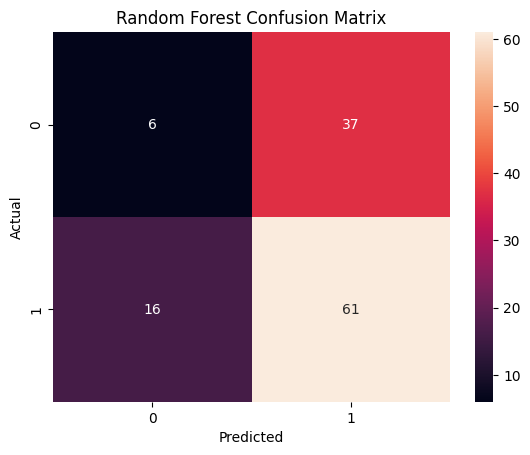

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()